# Celeb A Dataset
This is a project based on the CelebA dataset https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html

This dataset has 40 binary attributes annotations per image.

In [6]:
import sys
print(sys.executable)

e:\Advanced Python\.venv.generation_img\Scripts\python.exe


In [15]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [8]:
tfds.list_builders()

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asimov_v2_constraints_with_rationale',
 'asimov_v2_constraints_without_rationale',
 'asimov_v2_injuries',
 'asimov_v2_videos',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkel

In [4]:
# Possible error NonMatchingChecksumError due to Google Drive quota limits
# dataset, info = tfds.load('celeb_a', split='test', with_info=True, shuffle_files=False)
tfds_root = "datasets"
dataset, info = tfds.load('celeb_a', split='test', with_info=True, shuffle_files=False, data_dir=tfds_root)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling datasets\celeb_a\incomplete.BEWZD4_2.1.0\celeb_a-train.tfrecord-[0-9][0-9][0-9][0-9][0-9]-of-[0-9][0…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling datasets\celeb_a\incomplete.BEWZD4_2.1.0\celeb_a-validation.tfrecord-[0-9][0-9][0-9][0-9][0-9]-of-[0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling datasets\celeb_a\incomplete.BEWZD4_2.1.0\celeb_a-test.tfrecord-[0-9][0-9][0-9][0-9][0-9]-of-[0-9][0-…

Dataset celeb_a downloaded and prepared to datasets\celeb_a\2.1.0. Subsequent calls will reuse this data.


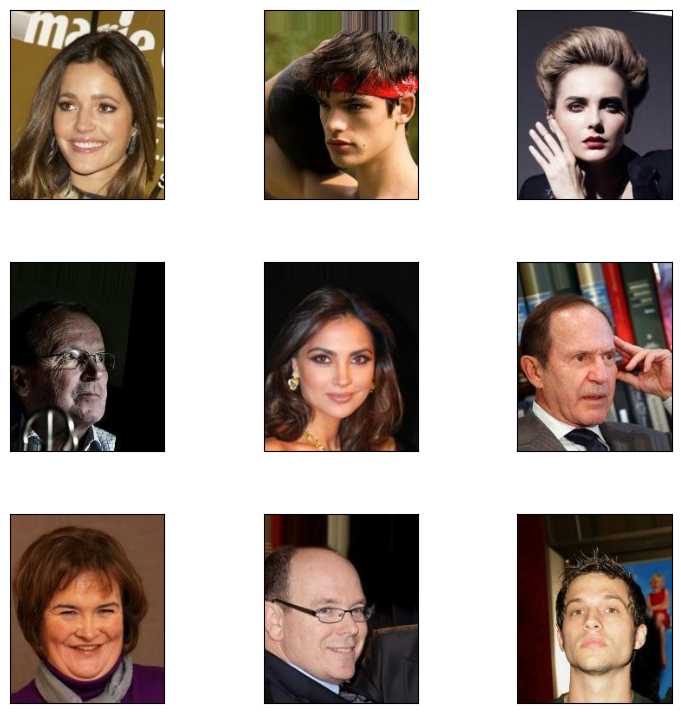

In [5]:
fig = tfds.show_examples(dataset, info)

In [6]:
print(info)

tfds.core.DatasetInfo(
    name='celeb_a',
    full_name='celeb_a/2.1.0',
    description="""
    CelebFaces Attributes Dataset (CelebA) is a large-scale face attributes dataset
    with more than 200K celebrity images, each with 40 attribute annotations. The
    images in this dataset cover large pose variations and background clutter.
    CelebA has large diversities, large quantities, and rich annotations,
    including - 10,177 number of identities, - 202,599 number of face images, and -
    5 landmark locations, 40 binary attributes annotations per image.
    
    The dataset can be employed as the training and test sets for the following
    computer vision tasks: face attribute recognition, face detection, and landmark
    (or facial part) localization.
    
    Note: CelebA dataset may contain potential bias. The fairness indicators
    [example](https://www.tensorflow.org/responsible_ai/fairness_indicators/tutorials/Fairness_Indicators_TFCO_CelebA_Case_Study)
    goes into det

In [32]:
batch_size = 5000
# Batch the dataset and get the shape of the images
dataset_batch = dataset.batch(batch_size)
# Get the first batch of images from the dataset
features = next(iter(dataset_batch))
print(features['attributes'])
dims = features['image'].shape
print(f'Shape of Tensor: {dims[0]} elements, Height: {dims[1]}, Width: {dims[2]}, Channels: {dims[3]}')

{'5_o_Clock_Shadow': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([False, False, False, ...,  True, False, False], shape=(5000,))>, 'Arched_Eyebrows': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([False, False,  True, ..., False, False, False], shape=(5000,))>, 'Attractive': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([ True, False,  True, ...,  True, False,  True], shape=(5000,))>, 'Bags_Under_Eyes': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([False,  True, False, ...,  True, False, False], shape=(5000,))>, 'Bald': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([False, False, False, ..., False,  True, False], shape=(5000,))>, 'Bangs': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([False,  True, False, ..., False, False,  True], shape=(5000,))>, 'Big_Lips': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([False,  True,  True, ..., False,  True, False], shape=(5000,))>, 'Big_Nose': <tf.Tensor: shape=(5000,), dtype=bool, numpy=array([False, False, F

In [17]:
# Function to display an image using matplotlib
def show_image(image):
  fig = plt.figure(figsize=(10, 8))
  plt.imshow(image.astype('uint8'))
  plt.axis('off')
  plt.show()

In [ ]:
# Function to generate an image by computing the mean of a set of sample images
def generate_image_mean(sample_images):
  return np.mean(sample_images, axis=0)

# Function to generate an image by computing the median of a set of sample images
def generate_image_median(sample_images):
  return np.median(sample_images, axis=0)

# Function to generate an image by computing the standard deviation of a set of sample images
def generate_image_std(sample_images):
  return np.std(sample_images, axis=0)

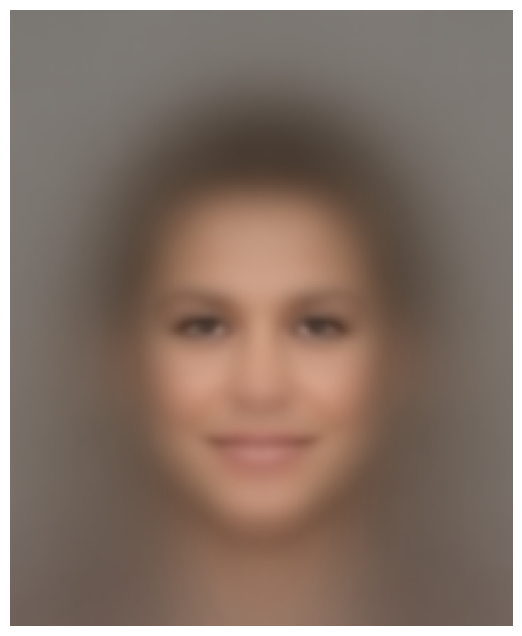

In [28]:
sample_images = features['image']
# Generate and display the mean image from the sample images
generated_image = generate_image_mean(sample_images)
show_image(generated_image)


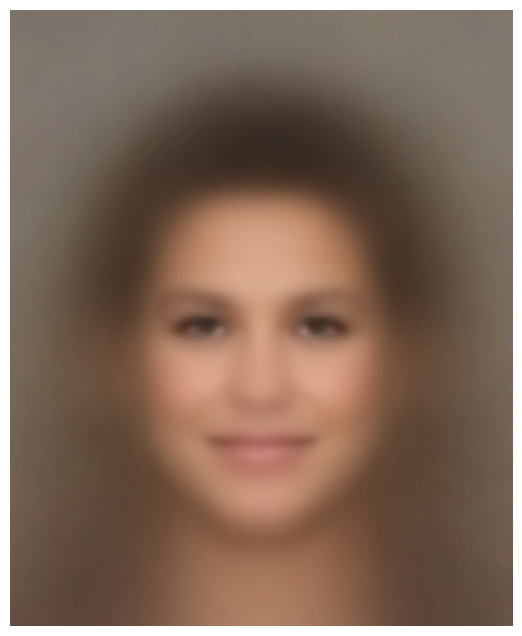

In [29]:
# Generate and display the median image from the sample images
generated_image_median = generate_image_median(sample_images)
show_image(generated_image_median)

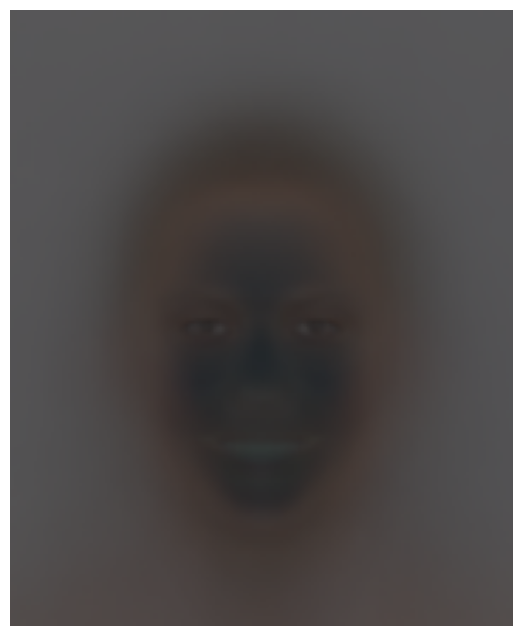

In [30]:
# Generate and display the standard deviation image from the sample images
generated_image_std = generate_image_std(sample_images)
show_image(generated_image_std)

In [33]:
def filter_batch(features, attributes, batch_size):
  filter_list = []
  for i in range(batch_size):
    match = True
    for key, value in attributes.items():
      if features['attributes'][key][i] != value:
        match = False
        break
    filter_list.append(match)
  return features['image'][np.array(filter_list, dtype=np.bool)]


In [34]:
# Function to filter a dataset based on specific attributes and return the filtered samples
def filter_dataset(dataset, attributes, batch_size, dims):
  samples = np.empty((0, dims[1], dims[2], dims[3]))
  for features in dataset.take(len(dataset)-1):
    sub_samples = filter_batch(features, attributes, batch_size)
    samples = np.append(samples, sub_samples, axis=0)
  return samples

Sample size: 108


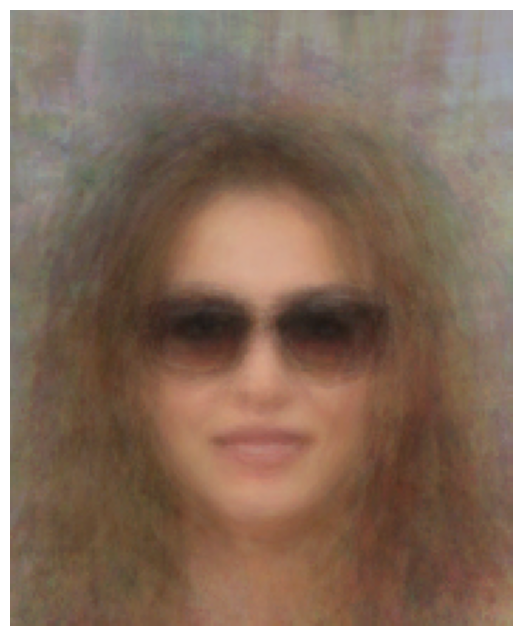

In [49]:
attributes = {
  'Young': True,
  'Male': False,
  'Eyeglasses': True,
  }

sample_images = filter_dataset(dataset_batch, attributes, batch_size, dims)
print(f'Sample size: {len(sample_images)}')
show_image(generate_image_median(sample_images))